# GEMM and MLP Layer

The MLP layer can be broken down into the following steps:

1 G = $X W_g$ 2048 x 4096, 4096 x 14336

2 U = $X W_u$ 2048 x 4096, 4096 x 14336

3 Z = $SiLU(G) \otimes U$ , 2048 x 14336, 2048 x 14336

4 Y = $Z W_d$ 2048 x 14336, 14336 x 4096

5 Residual

6 RMSNorm

MLP is tensor-operation intense, most of the on-chip happens on GEMM operations. The strategy for parallelize GEMM on SA1/SA2 uses the same idea in FA2: maximize the intensity of SA unit and non-GEMM operations run on the VCPU concurrently.

Ref: Pope et al., "Efficiently Scaling Transformer Inference" (arXiv:2211.05102)

In [1]:
import sys
if "code" not in sys.path: sys.path.insert(0, "code")   # model modules live in code/

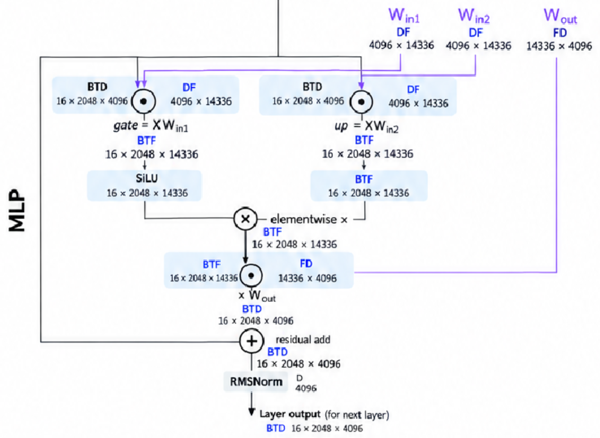

In [2]:
from helper import plot
from mlp import *
plot("img/MLP.png", 600)

## 1. MLP in Prefill

Tiling is essential for the MLP, as the following simple calculation shows:

In [3]:
# a whole weight matrix can not stay resident in SRAM
from helper import D, F
from tile_model import Hardware

sram = Hardware().sram_bytes
for name, rows, cols in [("Wg", D, F), ("Wu", D, F), ("Wd", F, D)]:
    b = rows * cols                      # INT8 weights, 1 byte each
    print(f"{name}: {b/2**20:5.1f} MiB   fits in {sram/2**20:.0f} MiB SRAM? {b <= sram}")


Wg:  56.0 MiB   fits in 16 MiB SRAM? False
Wu:  56.0 MiB   fits in 16 MiB SRAM? False
Wd:  56.0 MiB   fits in 16 MiB SRAM? False


Following the same setting as in FA2, all GEMM operations are carried out on the SA, while the VCPU handles the residual and RMSNorm parts.

3 For loops:

1 loop through sequence length T

2 loop through feature F

3 loop through reduction D

The tile size therefore: Mt x R @ R x Ft for SA


    FOR each token tile t (Mt rows)

        DMA  load X16 tile                    # prefetched one feature tile early
        VCPU quantize X16 -> X8 operands      # static SmoothQuant scale, one pass

        FOR each hidden-feature tile f (Ft columns)

            DMA  load Wg|Wu(f)                # slot reused after gate+up(f-2)
            DMA  load Wd(f)                   # slot reused after down(f-2)

            # ---- gate + up:  [Mt x 2Ft] = X8[Mt x D] . Wg|Wu[D x 2Ft]
            FOR each reduction chunk k across D (R = 256)
                SA1/SA2 compute X8 . Wg|Wu[k] partial products
                SRAM write raw INT16 partials
                VCPU G U 32 partials     # overlaps the next chunk
            VCPU last chunk: apply scales, Z = SiLU(G) * U,
                 quantize -> Z8 operands      # fused into the final accumulate

            # ---- down:  [Mt x D] += Z8[Mt x Ft] . Wd[Ft x D]
            FOR each reduction chunk k across Ft
                SA1/SA2 compute Z8 . Wd[k] partial products
                SRAM write raw INT16 partials
                VCPU Y32 (=|+=) partials      # queued after gate+up(f+2) work,
                                              # first chunk of f=0 writes Y32
        END FOR

        DMA  load residual X16 tile
        VCPU Y16 = Y32 + X16, output scale
        DMA  store Y16                        # overlaps the next token tile
    END FOR

In [4]:
# Mt = 64 on SA1 and 128 on SA2

In [5]:
# The parameter setting identical with FA2, A row split of 192 and R = 256 to maximize the performance

hw = Hardware()

mlp(M=2048, D=4096, F=14336, Mt=192, Ft=256, Mt_sa1=None, R=256,
        residual=True, hw=hw, overlap=True, verbose=True)["time_ms"]


x0 load X16                                DMA    @            0    24,976 cycles     24.976 us  SRAM   1536.00 KiB
x0 quantize X -> X8 operands               VCPU   @       24,976    18,732 cycles     18.732 us  SRAM   4370.00 KiB
x0 f0 load Wg|Wu                           DMA    @       24,976    33,168 cycles     33.168 us  SRAM   4370.00 KiB
x0 f0 gate+up k0                           ARRAYS @       58,144    45,796 cycles     45.796 us  SRAM   5092.00 KiB
x0 f256 load Wg|Wu                         DMA    @       58,144    33,168 cycles     33.168 us  SRAM   5092.00 KiB
x0 f256 load Wd                            DMA    @       91,312    16,784 cycles     16.784 us  SRAM   6116.00 KiB
x0 f0 G,U32 = k0                           VCPU   @      103,940     4,908 cycles      4.908 us  SRAM   6692.00 KiB
x0 f0 gate+up k256                         ARRAYS @      103,940    45,796 cycles     45.796 us  SRAM   6692.00 KiB
x0 f0 load Wd                              DMA    @      108,096    16,7

660.9044389999999

## 2. MLP Decoder



MLP in decoder has 1 sequence length (Same situation in FA GEMM), thus, we apply the same Transpose trick on the SA input to fulfill the rows:

1 G = $X W_g$ 16 x 1 x 4096, 4096 x 14336

2 U = $X W_u$ 16 x 1 x 4096, 4096 x 14336

3 Z = $SiLU(G) \otimes U$ , 16 x 1 x 14336, 1 x 14336

4 Y = $Z W_d$ 16 x1 x 14336, 14336 x 4096

The mapping is transposed (features on the array rows, the M tokens on the
16-wide output axis) because 16 tokens cannot fill the 48 rows of a job pass.

    # X16: [M, D]           M = decode batch, one new token per sequence
    # Wg8|Wu8^T: [2F, D]    INT8, per-row scales, pre-packed in array operand
    # Wd8^T:     [D, F]     layout in DRAM, TRANSPOSED w.r.t. prefill

    DMA  load X16                          # the whole step: M rows, a few hundred KiB
    VCPU quantize X16 -> X8^T operands     # [D, M], static SmoothQuant scale

    FOR each hidden-feature tile f (Ft features)

        DMA  load Wg|Wu^T(f)               # [2Ft, D], slot reused after gate+up(f-2)
        DMA  load Wd^T(f)                  # [D, Ft],  slot reused after down(f-2)

        # ---- gate + up:  [2Ft x M] = Wg|Wu^T[2Ft x D] . X8^T[D x M]
        FOR each reduction chunk k across D (R = 256)
            _**SA1/SA2 compute Wg|Wu^T[k] . X8^T[k] partial products**_
            SRAM write raw INT16 partials
            VCPU G32 U32 partials      # overlaps the next chunk
        VCPU last chunk: apply scales, Z = SiLU(G) * U,
             quantize -> Z8^T [Ft x M]     # fused into the final accumulate

        # ---- down:  [D x M] += Wd^T[D x Ft] . Z8^T[Ft x M]
        FOR each reduction chunk k across Ft
            SA1/SA2 compute Wd^T[k] . Z8^T[k] partial products
            SRAM write raw INT16 partials
            VCPU Y32 partials       # queued after gate+up(f+2) work
    END FOR

    DMA  load residual X16
    VCPU Y16 = Y32 + X16, output scale
    DMA  store Y16

Finally put all the component into the performance model:

In [6]:
mlp_decode(M=1, D=4096, F=14336, Ft=256, R=256,
        residual=True, hw=hw, overlap=True, verbose=True)["time_ms"]

load X16                                   DMA    @            0       528 cycles      0.528 us  SRAM      8.00 KiB
quantize X -> X8^T operands                VCPU   @          528       396 cycles      0.396 us  SRAM   2078.00 KiB
f0 load Wg|Wu^T                            DMA    @          528    33,168 cycles     33.168 us  SRAM   2078.00 KiB
f0 gate+up k0                              ARRAYS @       33,696     4,144 cycles      4.144 us  SRAM   4152.50 KiB
f256 load Wg|Wu^T                          DMA    @       33,696    33,168 cycles     33.168 us  SRAM   4152.50 KiB
f0 G,U32 = k0                              VCPU   @       37,840       448 cycles      0.448 us  SRAM   4171.00 KiB
f0 gate+up k256                            ARRAYS @       37,840     4,144 cycles      4.144 us  SRAM   4171.00 KiB
f0 G,U32 += k256                           VCPU   @       41,984       464 cycles      0.464 us  SRAM   4171.00 KiB
f0 gate+up k512                            ARRAYS @       41,984     4,1

5.467543